# **MÓDULO 13**
# Projeto - Fundamentos da Descoberta de Dados

Nesse projeto trabalharemos com a base de dados de produtos de um supermercado do Chile.
A ideia é que vocês apliquem os conceitos estatísticos vistos no último módulo, mais os conceitos de visualizações de dados através de gráficos e finalizem publicando no seu github!

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

Faça a leitura dos dados do arquivo CSV:


Altere o código abaixo de acordo com seu diretório.

In [2]:
df = pd.read_csv("../data/MODULO7_PROJETOFINAL_BASE_SUPERMERCADO.csv", delimiter=',')

df.head(10)

,title,Marca,Preco_Normal,Preco_Desconto,Preco_Anterior,Desconto,Categoria
0,"Pack 12 un, Leche extra proteína 1 L",Loncoleche,19788,0,0,0,lacteos
1,"Pack 12 un, Leche chocolate receta original 1 L",Soprole,18228,0,0,0,lacteos
2,"Pack 12 un, Leche semidescremada chocolate 1 L",Soprole,18228,0,0,0,lacteos
3,"Pack 12 un, Leche semidescremada frutilla 1 L",Soprole,18228,0,0,0,lacteos
4,"Pack 12 un, Leche sin lactosa chocolate 1 L",Loncoleche,17988,0,0,0,lacteos
5,"Pack 12 un, Leche sin lactosa frutilla 1 L",Loncoleche,17988,0,0,0,lacteos
6,"Pack 12 un, Leche saborizada light chocolate 1 L",Loncoleche,17988,0,0,0,lacteos
7,"Pack 12 un, Leche saborizada frutilla 1 L",Colun,17388,0,0,0,lacteos
8,"Pack 12 un, Leche saborizada vainilla 1 L",Colun,17388,0,0,0,lacteos
9,"Pack 12 un, Leche saborizada manjar 1 L",Colun,17388,0,0,0,lacteos


Os campos do nosso dataframe são:

**Title:** Nome do produto.


**Marca:** A marca do produto.


**Preco_Normal:** O preço em que o produto costuma ser vendido quando não há desconto.


**Preco_Desconto:** O preço vendido após o desconto ser aplicado.


**Preco_Anterior:** Preço em que era comercializado o produto antes do desconto aplicado.


**Desconto:** Total de desconto aplicado.






As colunas que aparecem com valores 0 são para os produtos onde não tivemos descontos aplicados.


As categorias estão em espanhol!

# 1 - Traga a média e a mediana dos preços - coluna Preco_Normal - por categoria de produto.
# Identifique as categorias que parecem ter um valor de média abaixo ou acima da mediana.

In [3]:
#Seu código aqui para a média
df.groupby('Categoria')['Preco_Normal'].mean()



Categoria
belleza-y-cuidado-personal    1783.556485
comidas-preparadas            3095.043478
congelados                    2108.042553
frutas                        1724.473684
instantaneos-y-sopas           765.491228
lacteos                       2385.219239
verduras                      1343.296875
Name: Preco_Normal, dtype: float64

In [4]:
#Seu código aqui para a mediana
df.groupby('Categoria')['Preco_Normal'].median()

Categoria
belleza-y-cuidado-personal    1569.0
comidas-preparadas            3290.0
congelados                    1519.0
frutas                        1195.0
instantaneos-y-sopas           439.0
lacteos                        989.0
verduras                      1180.0
Name: Preco_Normal, dtype: float64

In [5]:
stats = (
    df
    .groupby('Categoria')['Preco_Normal']
    .agg(['mean', 'median'])
    .sort_values(by='mean', ascending=False)
)

stats['diff'] = stats['mean'] - stats['median']

display(stats)

,mean,median,diff
Categoria,,,
comidas-preparadas,3095.043478,3290.0,-194.956522
lacteos,2385.219239,989.0,1396.219239
congelados,2108.042553,1519.0,589.042553
belleza-y-cuidado-personal,1783.556485,1569.0,214.556485
frutas,1724.473684,1195.0,529.473684
verduras,1343.296875,1180.0,163.296875
instantaneos-y-sopas,765.491228,439.0,326.491228


Digite aqui as categorias:

Média abaixo da Mediana:
- comidas-preparadas

Média acima da Mediana:
- lacteos
- congelados
- belleza-y-cuidado-personal
- frutas
- verduras
- instantaneos-y-sopas

# 2 - Traga o desvio padrão por categoria de produto.
# Qual o comportamento da média e mediana nas categorias com maior desvio?

In [6]:
#Seu código aqui
stats = (
    df
    .groupby('Categoria')['Preco_Normal']
    .agg(['mean', 'median', 'std'])
    .sort_values(by='std', ascending=False)
)

# coeficiente de variação
# cv < 0.5 -> baixa variabilidade
# 0.5 < cv < 1.0 -> variabilidade moderada
# cv > 1.0 -> muito disperso
stats['cv'] = stats['std'] / stats['mean']

stats.sort_values(by='cv', ascending=False)

display(stats)

,mean,median,std,cv
Categoria,,,,
lacteos,2385.219239,989.0,3925.816164,1.645893
belleza-y-cuidado-personal,1783.556485,1569.0,2210.041719,1.239121
congelados,2108.042553,1519.0,2111.539896,1.001659
comidas-preparadas,3095.043478,3290.0,2019.911428,0.652628
frutas,1724.473684,1195.0,1639.151114,0.950523
instantaneos-y-sopas,765.491228,439.0,1170.232869,1.528735
verduras,1343.296875,1180.0,1012.699625,0.753891


Digite nesse campo o comportamento que você identificou.
A maior parte das colunas (4/7) possui alta variabilidade:
- lacteos
- instantaneos-y-sopas
- belleza-y-cuidado-personal
- congelados

As outras 3 colunas possui uma variabilidade moderada
- frutas
- verduras
- comidas-preparadas

# 3 - Plot um boxplot da distribuição do Preco_Normal para a categoria que você identificou que tem o maior desvio padrão. Como é a distribuição desses dados segundo o boxplot? Você identifica muitos outliers?

Dica: Para trazer apenas os dados da categoria que você deseja você pode usar o df.loc[df['Categoria'] == 'CATEGORIA ESCOLHIDA'

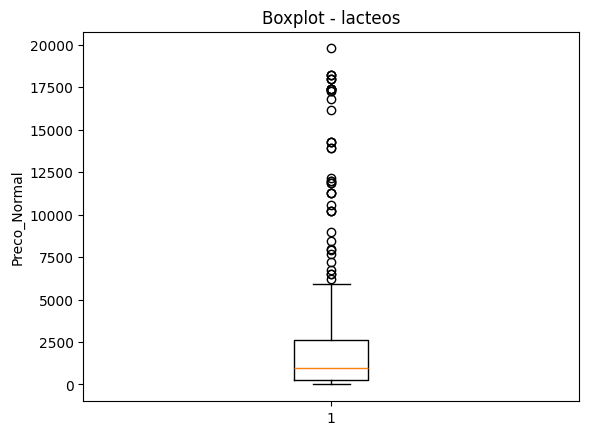

In [7]:
#Seu código aqui

# identificar a categoria com maior desvio de padrão
stats = (
    df
    .groupby('Categoria')['Preco_Normal']
    .agg(['std'])
    .sort_values(by='std', ascending=False)
)

categoria_top = stats.index[0]

# Filtrar os dados da categoria
df_cat = df.loc[df['Categoria'] == categoria_top]

# Plot do boxplot
import matplotlib.pyplot as plt

plt.figure()
plt.boxplot(df_cat['Preco_Normal'])
plt.title(f'Boxplot - {categoria_top}')
plt.ylabel('Preco_Normal')
plt.show()

# 4 - Plote um gráfico de barras onde temos a média de descontos por categoria.

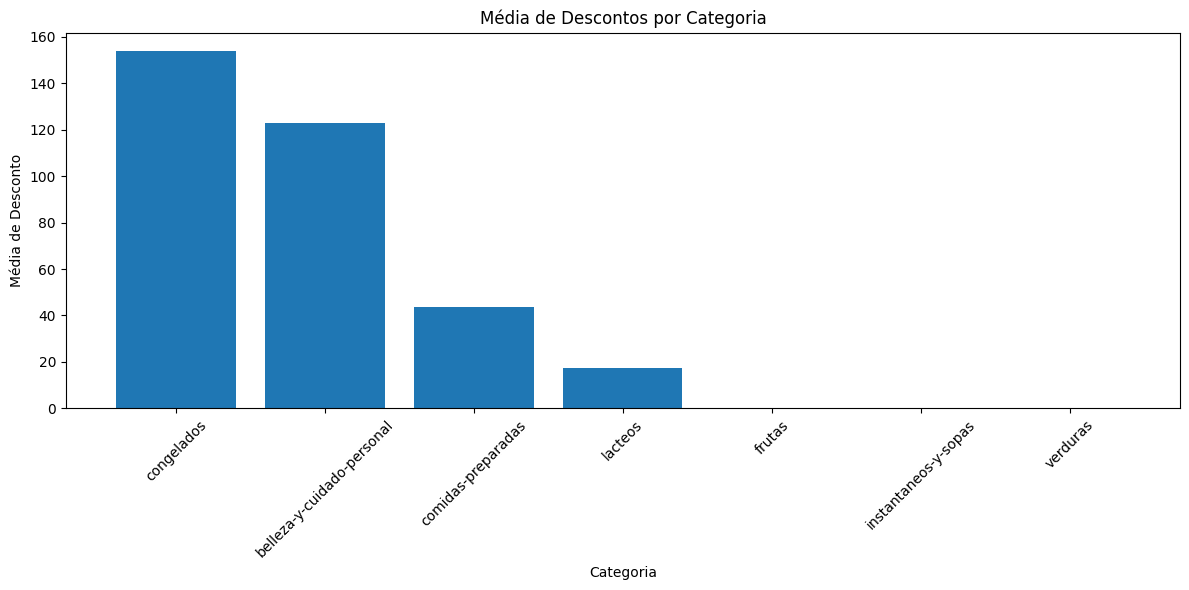

In [9]:
media_desconto = (
    df
    .groupby('Categoria')['Desconto']
    .mean()
    .sort_values(ascending=False)
)

# gráfico
plt.figure(figsize=(12, 6))
plt.bar(media_desconto.index, media_desconto.values)

plt.title('Média de Descontos por Categoria')
plt.xlabel('Categoria')
plt.ylabel('Média de Desconto')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

# 5 - Plote um gráfico de mapa interativo agrupando os dados por categoria, marca e trazendo a média de desconto.

In [11]:
# agregação
df_plot = (
    df
    .groupby(['Categoria', 'Marca'])['Desconto']
    .mean()
    .reset_index()
)

# treemap
fig = px.treemap(
    df_plot,
    path=['Categoria', 'Marca'],
    values='Desconto',
    color='Desconto',
    title='Média de Desconto por Categoria e Marca'
)

fig.show()